# Inductive Miner & Model Evaluation

Discover a process tree using the Inductive Miner, then evaluate the resulting model with fitness, precision, F1, and model size metrics.

In [1]:
import pm4py
from pm4py.objects.conversion.log import converter as log_converter
from pm4py.objects.conversion.process_tree import converter as pt_converter

## Load Event Log
Read an XES file for process discovery.

In [2]:
LOG_PATH = "../data/examples/repairExampleCompleteOnly.xes"
event_log = log_converter.apply(pm4py.read_xes(LOG_PATH))

print(f"Traces: {len(event_log)}")

c:\Users\safaya\Documents\GitHub\process-fragment-miner\.venv\Lib\site-packages\pm4py\utils.py:1027: UserWarning: Install the optional requirement `r4pm` to import/export files faster. `rustxes` remains supported as a fallback.
  warnings.warn(


parsing log, completed traces ::   0%|          | 0/1000 [00:00<?, ?it/s]

Traces: 1000


## Discover Process Tree
Use the Inductive Miner to discover a process tree from the event log.

In [3]:
process_tree = pm4py.discover_process_tree_inductive(event_log)

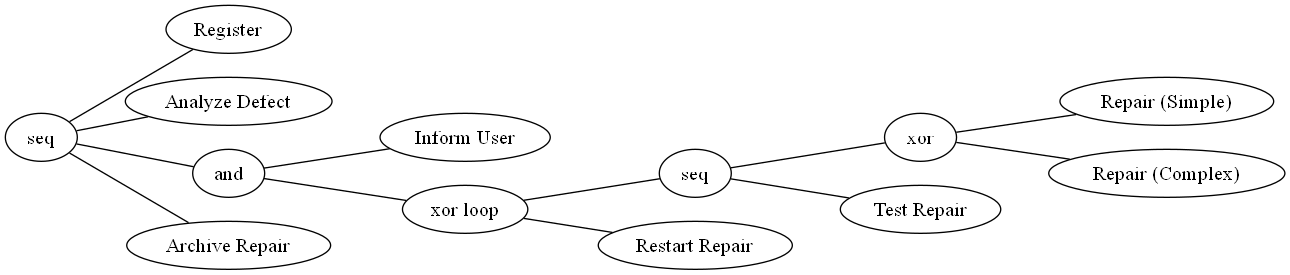

In [4]:
pm4py.view_process_tree(process_tree)

## Model Evaluation Metrics
Define a function that computes fitness, precision, F1, CFC, and model size by converting the process tree to a Petri net and running alignment-based conformance checking.

In [5]:
def calculate_metrics(model, event_log):
    """
    Computes fitness, precision, F1, CFC, and model size for a process model
    with respect to an event log.

    Args:
        model: A PM4Py ProcessTree, or a PetriNet tuple (net, initial_marking, final_marking).
        event_log: PM4Py EventLog object.

    Returns:
        dict: {"fi" (fitness), "pr" (precision), "F1", "CFC", "size"}.
    """
    if hasattr(model, 'children'):
        net, initial_marking, final_marking = pt_converter.apply(model)
    elif isinstance(model, tuple) and len(model) == 3:
        net, initial_marking, final_marking = model
    else:
        raise TypeError(f"Expected a ProcessTree or (PetriNet, marking, marking) tuple, got {type(model)}")

    log_fitness = pm4py.fitness_alignments(event_log, net, initial_marking, final_marking, multi_processing=False)['log_fitness']
    precision = pm4py.precision_alignments(event_log, net, initial_marking, final_marking, multi_processing=False)

    denominator = log_fitness + precision
    f1 = 2 * (log_fitness * precision) / denominator if denominator != 0 else 0.0

    size = len(net.places) + len(net.transitions) + len(net.arcs)

    return {
        "fi": log_fitness,
        "pr": precision,
        "F1": f1,
        "size": size
    }

## Compute Metrics
Evaluate the discovered model on the same event log.

In [7]:
metrics = calculate_metrics(process_tree, event_log)

print("=" * 50)
print("MODEL EVALUATION METRICS")
print("=" * 50)
print(f"Fitness:           {metrics['fi']:.4f}")
print(f"Precision:         {metrics['pr']:.4f}")
print(f"F1 Score:          {metrics['F1']:.4f}")
print(f"Model Size:        {metrics['size']}")

aligning log, completed variants ::   0%|          | 0/39 [00:00<?, ?it/s]

computing precision with alignments, completed variants ::   0%|          | 0/109 [00:00<?, ?it/s]

MODEL EVALUATION METRICS
Fitness:           1.0000
Precision:         0.9826
F1 Score:          0.9912
Model Size:        34
